## Overview

Interconnect, a telecom operator, wants to proactively identify customers likely to cancel their service. When a customer is flagged as high-risk, the marketing team can intervene with promotional codes and tailored plan offers before they leave.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from config import RAW_DATA

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, classification_report, f1_score, roc_auc_score
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

In [2]:
contract = pd.read_csv(RAW_DATA / 'contract.csv', na_values=['', ' ', 'N/A', 'null', 'None', '?'], keep_default_na=True)
personal = pd.read_csv(RAW_DATA / 'personal.csv', na_values=['', ' ', 'N/A', 'null', 'None', '?'], keep_default_na=True)
internet = pd.read_csv(RAW_DATA / 'internet.csv', na_values=['', ' ', 'N/A', 'null', 'None', '?'], keep_default_na=True)
phone = pd.read_csv(RAW_DATA / 'phone.csv', na_values=['', ' ', 'N/A', 'null', 'None', '?'], keep_default_na=True)

## Exploratory Data Analysis

### Contract DataSet

In [3]:
# Display the first few rows of the contract dataset
print("Contract Dataset:")
contract.head()

Contract Dataset:


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.50
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


In [4]:
# Display the information about the contract dataset
print("\nContract Dataset Info:")
print()
contract.info()
print()
print('CustomerId duplicates:', contract['customerID'].duplicated().sum())
print('CustomerId missing:', contract['customerID'].isna().sum())



Contract Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7032 non-null   float64
dtypes: float64(2), object(6)
memory usage: 440.3+ KB

CustomerId duplicates: 0
CustomerId missing: 0


- No customerID missing or duplicate
- 11 null values in TotalCharges column
- BeginDate and EndDate columns are object type

In [5]:
# Change dates columns from object to datetime
contract['BeginDate'] = pd.to_datetime(contract['BeginDate'], format='%Y-%m-%d', errors='coerce')
contract['EndDate'] = pd.to_datetime(contract['EndDate'], format='%Y-%m-%d 00:00:00', errors='coerce')

In [6]:
# Create Churned column (target). If EndDate is not null (after converting it to datetime), 
# it means user has churned.
contract['Churned'] = contract['EndDate'].notna().astype(int)

In [7]:
# Create Tenure column.
# For active users, I will take the max date in EndDate column.
snapshot_date = contract['EndDate'].max()

temp_end = contract['EndDate'].fillna(snapshot_date)

contract['TenureMonths'] = (
    (temp_end.dt.year - contract['BeginDate'].dt.year) * 12 +
    (temp_end.dt.month - contract['BeginDate'].dt.month)
)

In [8]:
# Filling missing total charges with monthly charges
contract['TotalCharges'] = contract['TotalCharges'].fillna(contract['MonthlyCharges'])

In [9]:
# Values from categorical features
contract_features = ['Type','PaperlessBilling', 'PaymentMethod']

for i in contract_features:
    print(contract[i].value_counts())
    print()

Type
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64



In [10]:
# Display the first few rows of the contract dataset after preprocessing
print("\nContract Dataset after preprocessing:")
contract.head()


Contract Dataset after preprocessing:


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churned,TenureMonths
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,29.85,0,0
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,1889.50,0,33
2,3668-QPYBK,2019-10-01,2019-12-01,Month-to-month,Yes,Mailed check,53.85,108.15,1,2
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,1840.75,0,44
4,9237-HQITU,2019-09-01,2019-11-01,Month-to-month,Yes,Electronic check,70.70,151.65,1,2


- 7043 distinct clientIDs

- BeginDate and EndDate set to datetime

- Not a number (NaT) values in the EndDate column mean user is still active.

- Created a 'Churned' column (0: Active, 1:Churned)

- Created a 'TenureMonths' column. For active users, the end date is taken from the max value in the BeginDate column.

- Filled TotalCharges null values with their monthly charges.

### Personal DataSet

In [11]:
print("Personal Dataset:")
personal.head()

Personal Dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [12]:
print("\nPersonal Dataset Info:")
personal.info()
print()
print('CustomerId duplicates:', personal['customerID'].duplicated().sum())
print('CustomerId missing:', personal['customerID'].isna().sum())


Personal Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB

CustomerId duplicates: 0
CustomerId missing: 0


- 7043 distinct customerIDs without missing values
- gender column name not capitalized
- SeniorCitizen column is of int64 type

In [13]:
# Capitalize gender column name
personal.rename(columns={'gender':'Gender'}, inplace=True)

In [14]:
# Values from categorical features
personal_features = personal.columns.to_numpy()
personal_features = np.delete(personal_features, 0)

for i in personal_features:
    print(personal[i].value_counts())
    print()

Gender
Male      3555
Female    3488
Name: count, dtype: int64

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
No     4933
Yes    2110
Name: count, dtype: int64



### Internet DataSet

In [15]:
print("Internet Dataset:")
internet.head()

Internet Dataset:


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


In [16]:
print("\nInternet Dataset Info:")
print()
internet.info()
print()
print('CustomerId duplicates:', internet['customerID'].duplicated().sum())
print('CustomerId missing:', internet['customerID'].isna().sum())


Internet Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB

CustomerId duplicates: 0
CustomerId missing: 0


- 5517 distinct customerIDs with internet services without missing values
- Less clients than the contract dataset, meaning not all clients have internet services.

In [17]:
# Values from categorical features
internet_features = internet.columns.to_numpy()
internet_features = np.delete(internet_features, 0)

for i in internet_features:
    print(internet[i].value_counts())
    print()

InternetService
Fiber optic    3096
DSL            2421
Name: count, dtype: int64

OnlineSecurity
No     3498
Yes    2019
Name: count, dtype: int64

OnlineBackup
No     3088
Yes    2429
Name: count, dtype: int64

DeviceProtection
No     3095
Yes    2422
Name: count, dtype: int64

TechSupport
No     3473
Yes    2044
Name: count, dtype: int64

StreamingTV
No     2810
Yes    2707
Name: count, dtype: int64

StreamingMovies
No     2785
Yes    2732
Name: count, dtype: int64



### Phone DataSet

In [18]:
print("Phone Dataset:")
phone.head()

Phone Dataset:


,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [19]:
print("\nPhone Dataset Info:")
print()
phone.info()
print()
print('CustomerId duplicates:', phone['customerID'].duplicated().sum())
print('CustomerId missing:', phone['customerID'].isna().sum())


Phone Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB

CustomerId duplicates: 0
CustomerId missing: 0


- 6361 distinct cusomerIDs without missing values

In [20]:
print(phone['MultipleLines'].value_counts())

MultipleLines
No     3390
Yes    2971
Name: count, dtype: int64


### Merging DataSets

In [21]:
# Merging datasets and create a copy for preprocessing
df_merged = contract.merge(personal, on='customerID', how='left').merge(internet, on='customerID', how='left').merge(phone, on='customerID', how='left')
df_prepped = df_merged.copy()

In [22]:
print("Merged Dataset:")
df_prepped.head()

Merged Dataset:


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churned,TenureMonths,...,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,...,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,1889.50,0,33,...,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01,Month-to-month,Yes,Mailed check,53.85,108.15,1,2,...,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,1840.75,0,44,...,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,2019-11-01,Month-to-month,Yes,Electronic check,70.70,151.65,1,2,...,No,No,Fiber optic,No,No,No,No,No,No,No


In [23]:
print("\nMerged Dataset Info:")
print()
df_prepped.info()
print()
print('CustomerId duplicates:', df_prepped['customerID'].duplicated().sum())
print('CustomerId missing:', df_prepped['customerID'].isna().sum())


Merged Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           1869 non-null   datetime64[ns]
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   float64       
 8   Churned           7043 non-null   int64         
 9   TenureMonths      7043 non-null   int32         
 10  Gender            7043 non-null   object        
 11  SeniorCitizen     7043 non-null   int64         
 12  Partner           7043 non-null   object        
 13  Dependents        7043 non-null   object        
 14  I

- Missing values from internet and phone services related columns indicate clients do not have those services.
- EndDate missing values indicate user is still active

In [24]:
print("\nMissing Values in Merged Dataset:")
df_prepped.isna().sum()


Missing Values in Merged Dataset:


customerID             0
BeginDate              0
EndDate             5174
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
Churned                0
TenureMonths           0
Gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
InternetService     1526
OnlineSecurity      1526
OnlineBackup        1526
DeviceProtection    1526
TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
MultipleLines        682
dtype: int64

In [25]:
# Create HasInternet and HasPhone columns
internet_cols = internet_features.tolist()

df_prepped['HasInternet'] = df_prepped['InternetService'].notna().astype(int)
df_prepped['HasPhone'] = df_prepped['MultipleLines'].notna().astype(int)

# Fill internet and phone related columns missing values with 'No'
df_prepped[internet_cols] = df_prepped[internet_cols].fillna('No')
df_prepped['MultipleLines'] = df_prepped['MultipleLines'].fillna('No')

## Data Visualization

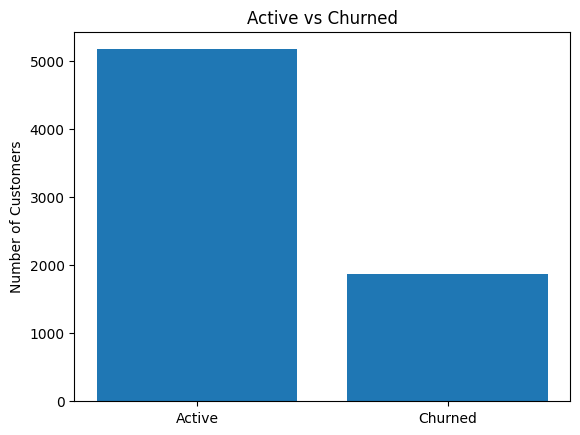

Churned
0    5174
1    1869
Name: count, dtype: int64


Churned
0    73.46
1    26.54
Name: proportion, dtype: float64

In [26]:
# Checking class imbalance
is_active = df_prepped['Churned'].value_counts().sort_index()

plt.figure()
plt.bar(is_active.index, is_active.values)
plt.xticks([0,1], ['Active', 'Churned'])
plt.ylabel('Number of Customers')
plt.title('Active vs Churned')

plt.show()

print(is_active)

(df_prepped["Churned"]
 .value_counts(normalize=True)
 .mul(100)
 .round(2))

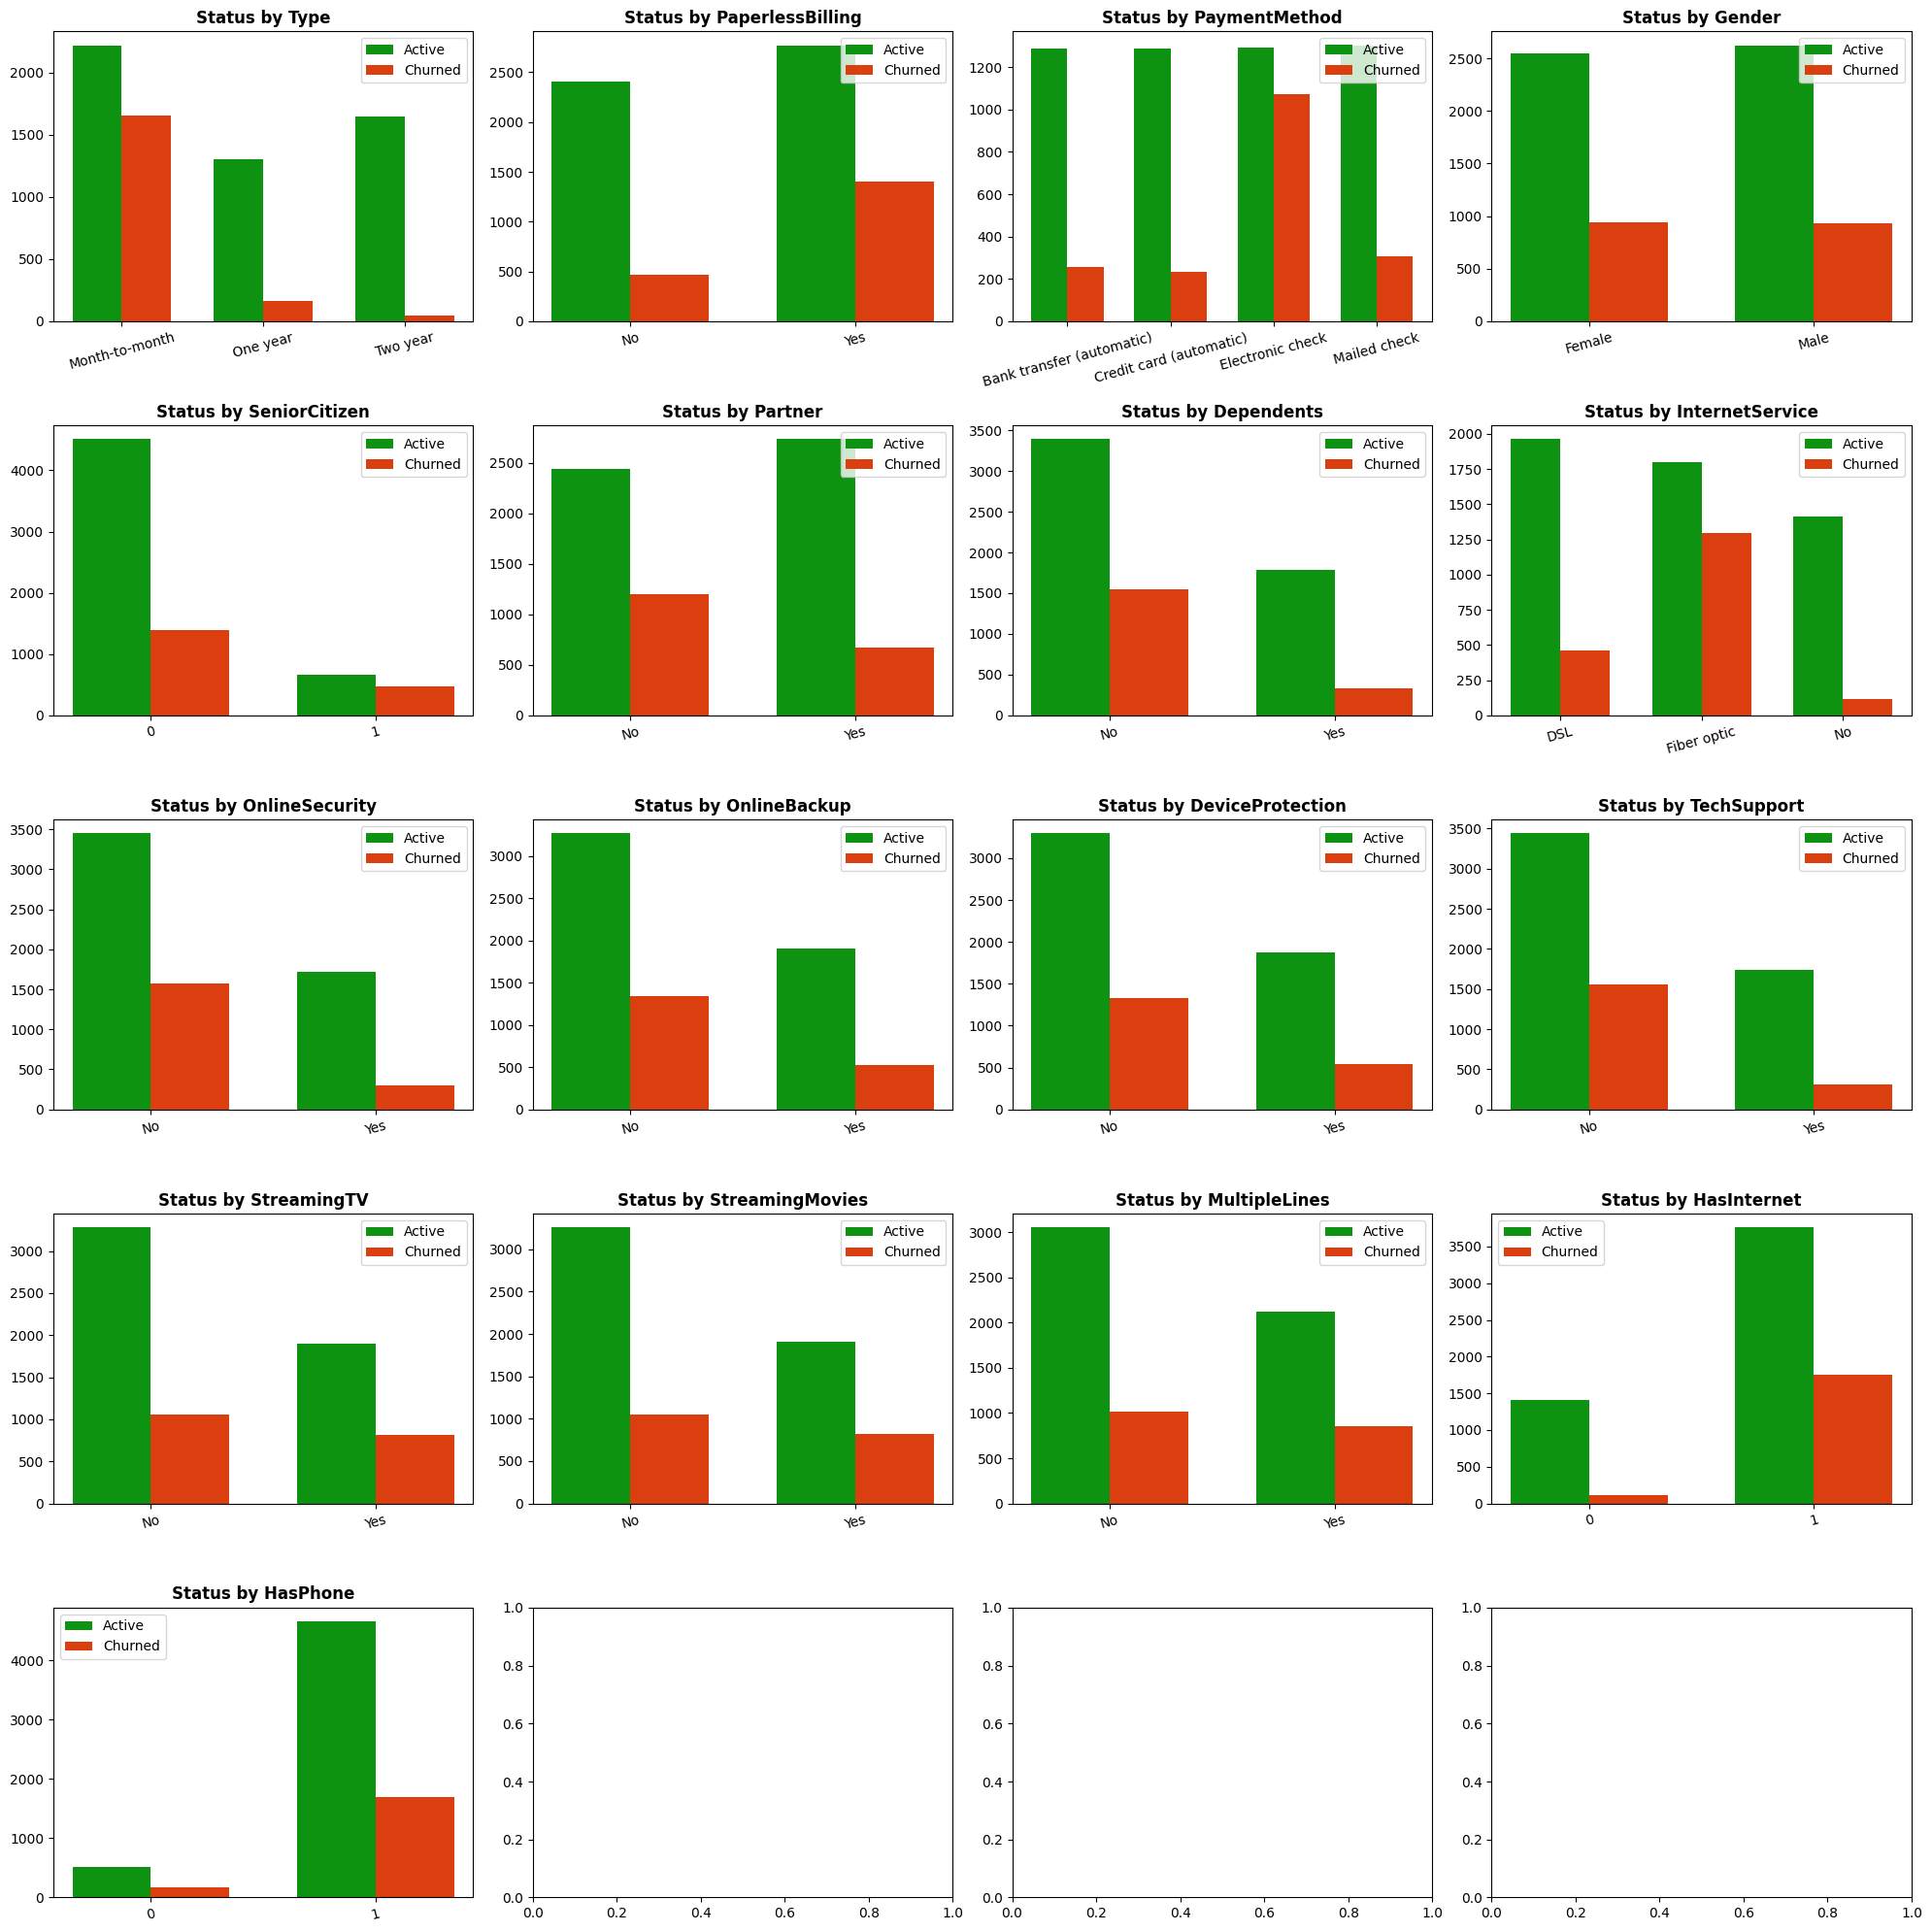

In [27]:
# Analyzing categorical data
categorical_features = list(df_prepped.select_dtypes(include=['object', 'int64']).columns)
categorical_features = [feat for feat in categorical_features if feat not in ['customerID', 'Churned']]

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20,20))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    active = df_prepped[contract['Churned'] == 0][col].value_counts().sort_index()
    churned = df_prepped[contract['Churned'] == 1][col].value_counts().sort_index()

    labels = active.index
    x = np.arange(len(labels))
    width = 0.35

    axes[i].bar(x - width/2, active, width, label='Active', color="#0D9211")
    axes[i].bar(x + width/2, churned, width, label='Churned', color="#DB3F0F")

    axes[i].set_title(f'Status by {col}', fontweight='bold')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(labels, rotation=15)
    axes[i].legend()

plt.tight_layout()
plt.show()

In [28]:
for i in categorical_features:
    print(df_prepped.groupby(i)['Churned'].value_counts(normalize=True))
    print()

Type            Churned
Month-to-month  0          0.572903
                1          0.427097
One year        0          0.887305
                1          0.112695
Two year        0          0.971681
                1          0.028319
Name: proportion, dtype: float64

PaperlessBilling  Churned
No                0          0.836699
                  1          0.163301
Yes               0          0.664349
                  1          0.335651
Name: proportion, dtype: float64

PaymentMethod              Churned
Bank transfer (automatic)  0          0.832902
                           1          0.167098
Credit card (automatic)    0          0.847569
                           1          0.152431
Electronic check           0          0.547146
                           1          0.452854
Mailed check               0          0.808933
                           1          0.191067
Name: proportion, dtype: float64

Gender  Churned
Female  0          0.730791
        1          0.2692

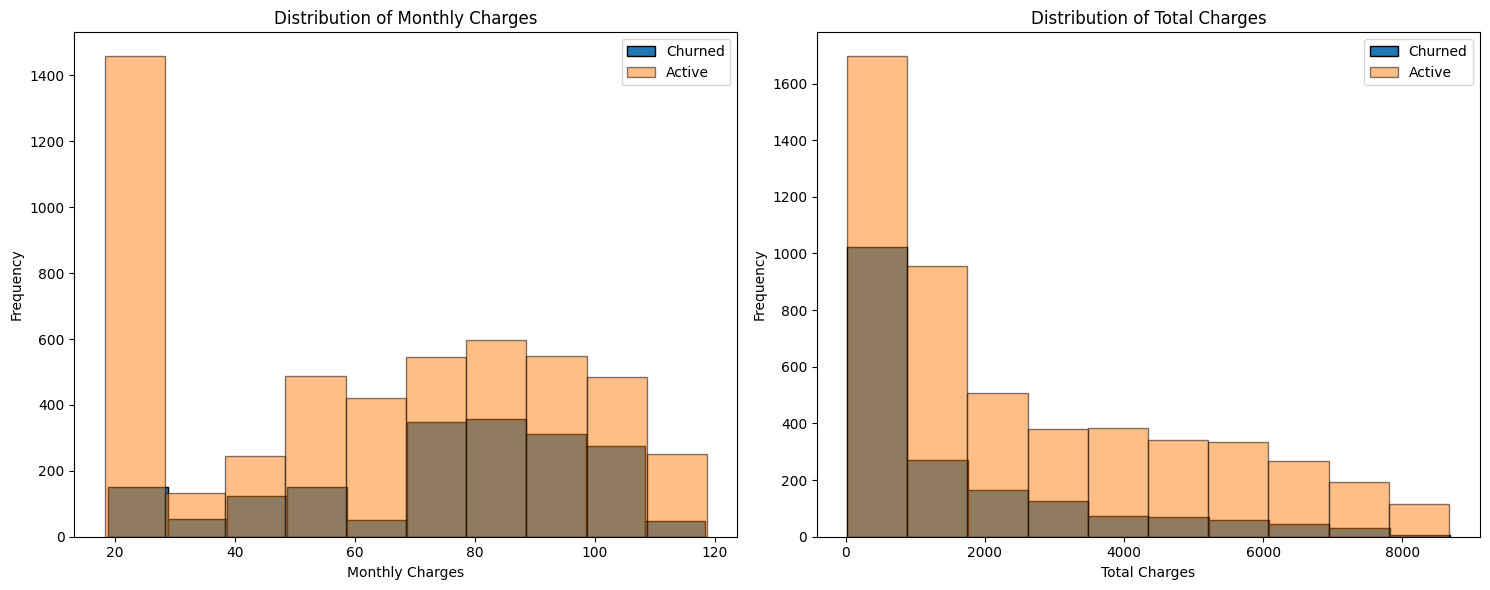

In [29]:
# Analyzing numerical data
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,6))

df_prepped[df_prepped['Churned'] == 1]['MonthlyCharges'].plot(
    kind='hist', edgecolor='black', ax=axes[0], label='Churned'
)
df_prepped[df_prepped['Churned'] == 0]['MonthlyCharges'].plot(
    kind='hist', alpha=0.5, edgecolor='black', ax=axes[0], label='Active'
)
axes[0].set_title('Distribution of Monthly Charges')
axes[0].set_xlabel('Monthly Charges')
axes[0].legend()

df_prepped[df_prepped['Churned'] == 1]['TotalCharges'].plot(
    kind='hist', edgecolor='black', ax=axes[1], label='Churned'
)
df_prepped[df_prepped['Churned'] == 0]['TotalCharges'].plot(
    kind='hist', alpha=0.5, edgecolor='black', ax=axes[1], label='Active'
)
axes[1].set_title('Distribution of Total Charges')
axes[1].set_xlabel('Total Charges')
axes[1].legend()

plt.tight_layout()
plt.show()

In [30]:
# Descriptive statistics for Monthly Charges
print('Active')
print(df_prepped[df_prepped['Churned'] == 0]['MonthlyCharges'].describe())
print()
print('Churned')
print(df_prepped[df_prepped['Churned'] == 1]['MonthlyCharges'].describe())

Active
count    5174.000000
mean       61.265124
std        31.092648
min        18.250000
25%        25.100000
50%        64.425000
75%        88.400000
max       118.750000
Name: MonthlyCharges, dtype: float64

Churned
count    1869.000000
mean       74.441332
std        24.666053
min        18.850000
25%        56.150000
50%        79.650000
75%        94.200000
max       118.350000
Name: MonthlyCharges, dtype: float64


<Axes: title={'center': 'MonthlyCharges'}, xlabel='Churned'>

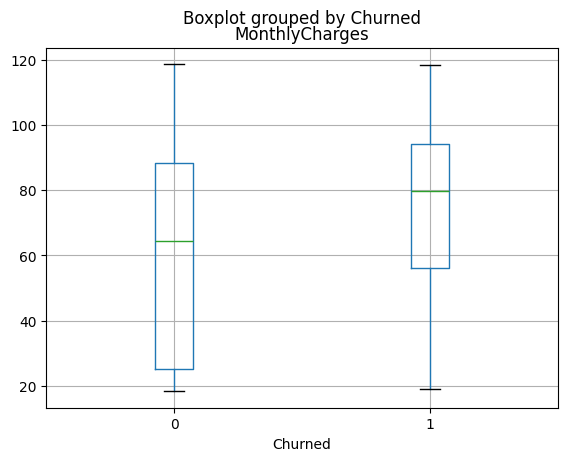

In [31]:
# Boxplot for Monthly Charges by Churned status
df_prepped.boxplot(column='MonthlyCharges', by='Churned')

In [32]:
# Descriptive statistics for Total Charges
print('Active')
print(df_prepped[df_prepped['Churned'] == 0]['TotalCharges'].describe())
print()
print('Churned')
print(df_prepped[df_prepped['Churned'] == 1]['TotalCharges'].describe())

Active
count    5174.000000
mean     2549.999497
std      2329.858843
min        18.800000
25%       572.900000
50%      1679.525000
75%      4262.850000
max      8672.450000
Name: TotalCharges, dtype: float64

Churned
count    1869.000000
mean     1531.796094
std      1890.822994
min        18.850000
25%       134.500000
50%       703.550000
75%      2331.300000
max      8684.800000
Name: TotalCharges, dtype: float64


<Axes: title={'center': 'TotalCharges'}, xlabel='Churned'>

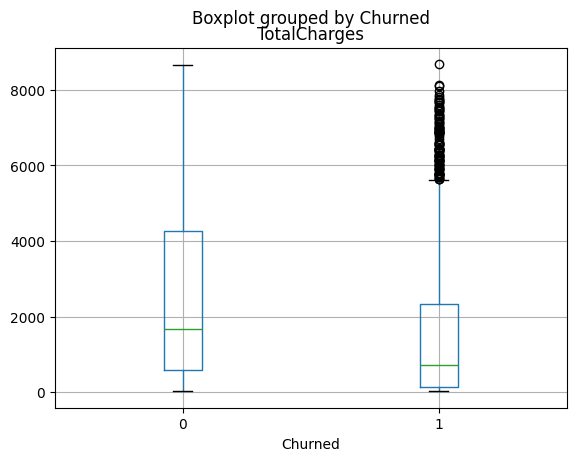

In [33]:
# Boxplot for Monthly Charges by Churned status
df_prepped.boxplot(column='TotalCharges', by='Churned')

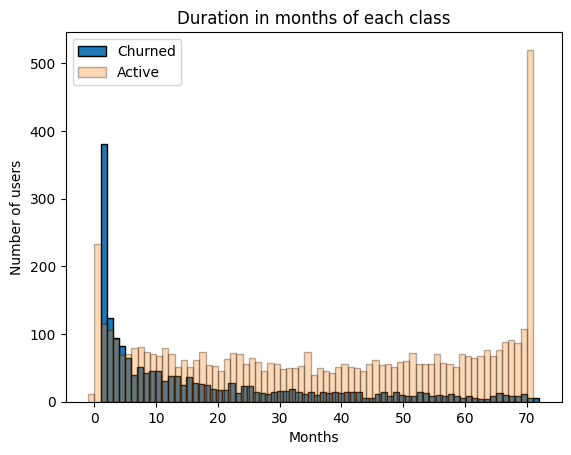

In [34]:
# Distribution of TenureMonths by Churned status
df_prepped[df_prepped['Churned'] == 1]['TenureMonths'].plot(
    kind='hist', bins=72, edgecolor='black', label='Churned')

df_prepped[df_prepped['Churned'] == 0]['TenureMonths'].plot(
    kind='hist', bins=72, alpha=0.3, edgecolor='black', label='Active')

plt.xlabel('Months')
plt.ylabel('Number of users')
plt.title("Duration in months of each class")
plt.legend()
plt.show()

In [35]:
# Descriptive statistics for TenureMonths
print('Active')
print(df_prepped[df_prepped['Churned'] == 0]['TenureMonths'].describe())
print()
print('Churned')
print(df_prepped[df_prepped['Churned'] == 1]['TenureMonths'].describe())

Active
count    5174.000000
mean       36.569965
std        24.113777
min        -1.000000
25%        14.000000
50%        37.000000
75%        60.000000
max        71.000000
Name: TenureMonths, dtype: float64

Churned
count    1869.000000
mean       17.979133
std        19.531123
min         1.000000
25%         2.000000
50%        10.000000
75%        29.000000
max        72.000000
Name: TenureMonths, dtype: float64


<Axes: title={'center': 'TenureMonths'}, xlabel='Churned'>

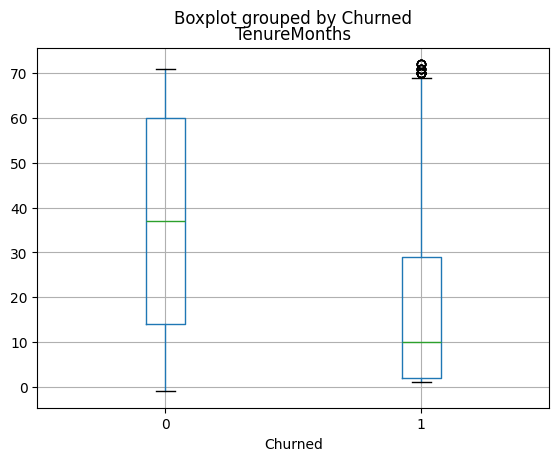

In [36]:
# Boxplot for TenureMonths by Churned status
df_prepped.boxplot(column='TenureMonths', by='Churned')

## Data Preprocessing

In [37]:
#Drop features not useful for training
fields_to_drop = ['customerID', 'BeginDate', 'EndDate']

#Create two sets: one will be manually encode categorical features
df_final = df_prepped.drop(fields_to_drop, axis=1)
df_final_enc = df_final.copy()

In [38]:
df_final_enc.head()

,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churned,TenureMonths,Gender,SeniorCitizen,Partner,...,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,HasInternet,HasPhone
0,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,Female,0,Yes,...,DSL,No,Yes,No,No,No,No,No,1,0
1,One year,No,Mailed check,56.95,1889.50,0,33,Male,0,No,...,DSL,Yes,No,Yes,No,No,No,No,1,1
2,Month-to-month,Yes,Mailed check,53.85,108.15,1,2,Male,0,No,...,DSL,Yes,Yes,No,No,No,No,No,1,1
3,One year,No,Bank transfer (automatic),42.30,1840.75,0,44,Male,0,No,...,DSL,Yes,No,Yes,Yes,No,No,No,1,0
4,Month-to-month,Yes,Electronic check,70.70,151.65,1,2,Female,0,No,...,Fiber optic,No,No,No,No,No,No,No,1,1


In [39]:
#Missing values
print("Missing values:", df_final_enc.isna().sum().sum())

Missing values: 0


In [40]:
#Mapping binary categoricals

binary_fields = ['PaperlessBilling', 
                 'Partner', 
                 'Dependents', 
                 'OnlineSecurity', 
                 'OnlineBackup', 
                 'DeviceProtection', 
                 'TechSupport', 
                 'StreamingTV', 
                 'StreamingMovies', 
                 'MultipleLines'
                 ]

for i in binary_fields:
    df_final_enc[i] = df_final_enc[i].map({'No':0, 'Yes':1})

df_final_enc['Gender'] = df_final_enc['Gender'].map({'Female':0, 'Male':1})

In [41]:
# OHE for Internet Service and Payment Method
df_final_enc = pd.get_dummies(df_final_enc, columns=['InternetService', 'PaymentMethod'], drop_first=False)

In [42]:
# Ordinal encoder for type of contract
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_final_enc['Type'] = encoder.fit_transform(df_final_enc[['Type']])

In [43]:
# Sample of encoded dataset
df_final_enc.sample(5)

,Type,PaperlessBilling,MonthlyCharges,TotalCharges,Churned,TenureMonths,Gender,SeniorCitizen,Partner,Dependents,...,MultipleLines,HasInternet,HasPhone,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
6103,0.0,0,19.75,294.90,0,15,1,0,0,0,...,0,0,1,False,False,True,False,True,False,False
1189,0.0,0,85.70,256.75,0,2,1,0,0,0,...,0,1,1,False,True,False,False,True,False,False
3068,1.0,1,96.40,4911.05,0,50,1,0,1,0,...,1,1,1,False,True,False,False,True,False,False
2733,0.0,1,55.30,55.30,0,0,0,0,1,0,...,0,1,1,True,False,False,False,False,False,True
2007,0.0,1,80.20,181.10,1,2,1,0,0,0,...,0,1,1,False,True,False,False,False,True,False


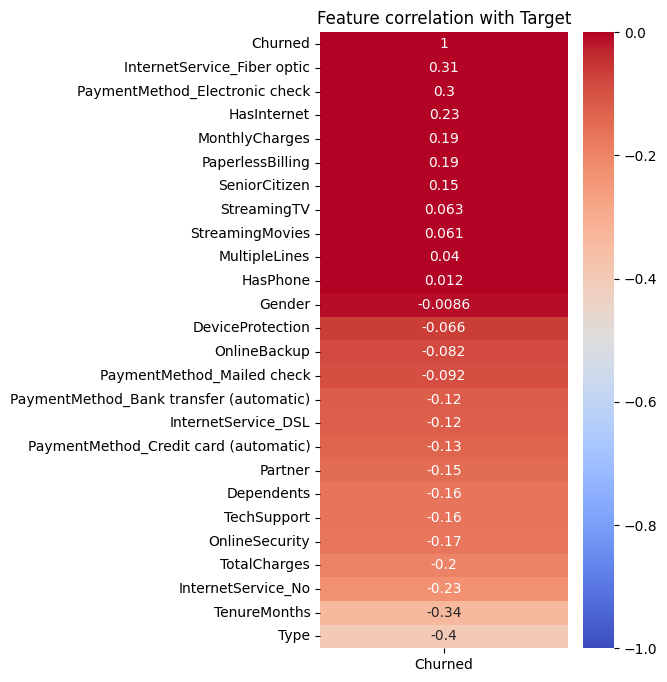

In [44]:
# Feature correlation map with Target
target_corr = df_final_enc.corr()['Churned'].sort_values(ascending=False).to_frame()

plt.figure(figsize=(4,8))
sns.heatmap(target_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=0)
plt.title("Feature correlation with Target")
plt.show()

## Model Training

In [45]:
#Split encoded set
X_enc = df_final_enc.drop('Churned', axis=1)
y_enc = df_final_enc['Churned']

X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(X_enc, y_enc, test_size=0.20, random_state=42)

#### Dummy Classifier (Baseline)

DUMMY CLASSIFIER TEST SET PERFORMANCE
accuracy: 0.74
recall: 0.00

auc_roc: 0.50
f1 score: 0.00

report:               precision    recall  f1-score   support

           0       0.74      1.00      0.85      1036
           1       0.00      0.00      0.00       373

    accuracy                           0.74      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.74      0.62      1409



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

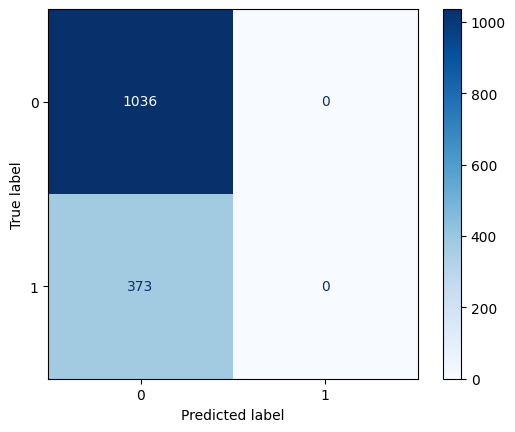

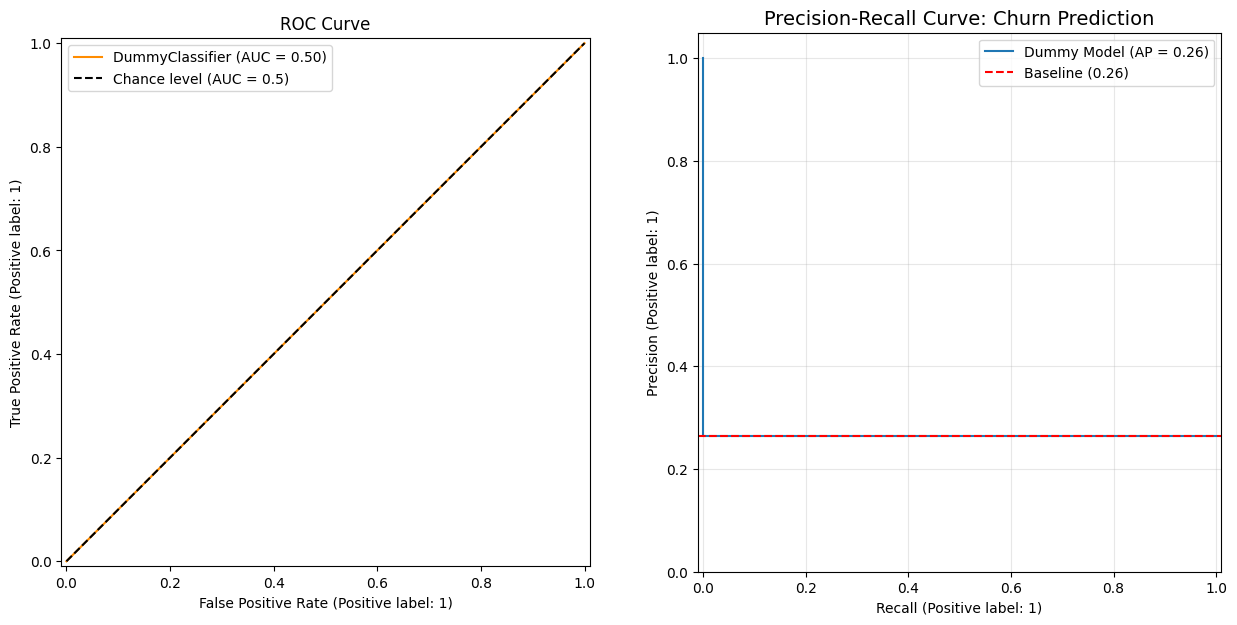

In [46]:
# Use 'most_frequent' to see the "lazy" accuracy baseline
model_dummy = DummyClassifier(strategy='most_frequent', random_state=42)
model_dummy.fit(X_train_enc, y_train_enc)

# Prediction for both sets 
train_pred_dummy = model_dummy.predict(X_train_enc)
test_pred_dummy = model_dummy.predict(X_test_enc)

train_probs_dummy = model_dummy.predict_proba(X_train_enc)[:, 1]
test_probs_dummy = model_dummy.predict_proba(X_test_enc)[:, 1]

'''
# Train Metrics
train_auc_roc_dummy = roc_auc_score(y_train_enc, train_probs_dummy)
train_recall_dummy = recall_score(y_train_enc, train_pred_dummy)
train_report_dummy = classification_report(y_train_enc, train_pred_dummy)
'''

#Test Metrics
test_accuracy_dummy = accuracy_score(y_test_enc, test_pred_dummy)
test_recall_dummy = recall_score(y_test_enc, test_pred_dummy)

test_auc_roc_dummy = roc_auc_score(y_test_enc, test_probs_dummy)
test_f1_dummy = f1_score(y_test_enc, test_probs_dummy)
test_report_dummy = classification_report(y_test_enc, test_pred_dummy)

ConfusionMatrixDisplay.from_estimator(model_dummy, X_test_enc, y_test_enc, cmap='Blues')

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,7))

RocCurveDisplay.from_estimator(model_dummy, X_test_enc, y_test_enc, ax=ax1, color='darkorange')
ax1.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)")
ax1.set_title("ROC Curve")
ax1.legend()

PrecisionRecallDisplay.from_estimator(model_dummy, X_test_enc, y_test_enc, name="Dummy Model", ax=ax2)
baseline = y_test_enc.sum() / len(y_test_enc)
ax2.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline ({baseline:.2f})')
ax2.set_title("Precision-Recall Curve: Churn Prediction", fontsize=14)
ax2.set_ylim([0.0, 1.05])
ax2.grid(alpha=0.3)
ax2.legend(loc="upper right")

'''
print("DUMMY CLASSIFIER TRAIN SET PERFORMANCE")
print(f"auc_roc: {train_auc_roc_dummy:.2f}")
print(f"recall: {train_recall_dummy:.2f}")
print("report:", train_report_dummy)
'''

print("DUMMY CLASSIFIER TEST SET PERFORMANCE")
print(f"accuracy: {test_accuracy_dummy:.2f}")
print(f"recall: {test_recall_dummy:.2f}")
print()
print(f"auc_roc: {test_auc_roc_dummy:.2f}")
print(f"f1 score: {test_f1_dummy:.2f}")
print()
print("report:", test_report_dummy)

plt.tight_layout
plt.show()

#### Logistic Regression

LOGISTIC REGRESSION TEST SET PERFORMANCE
accuracy: 0.75
recall: 0.83

auc_roc: 0.86
f1 score: 0.64

report:               precision    recall  f1-score   support

           0       0.92      0.73      0.81      1036
           1       0.52      0.83      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.78      0.72      1409
weighted avg       0.81      0.75      0.77      1409



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


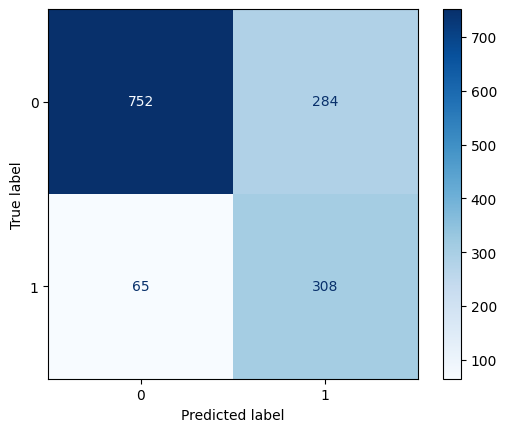

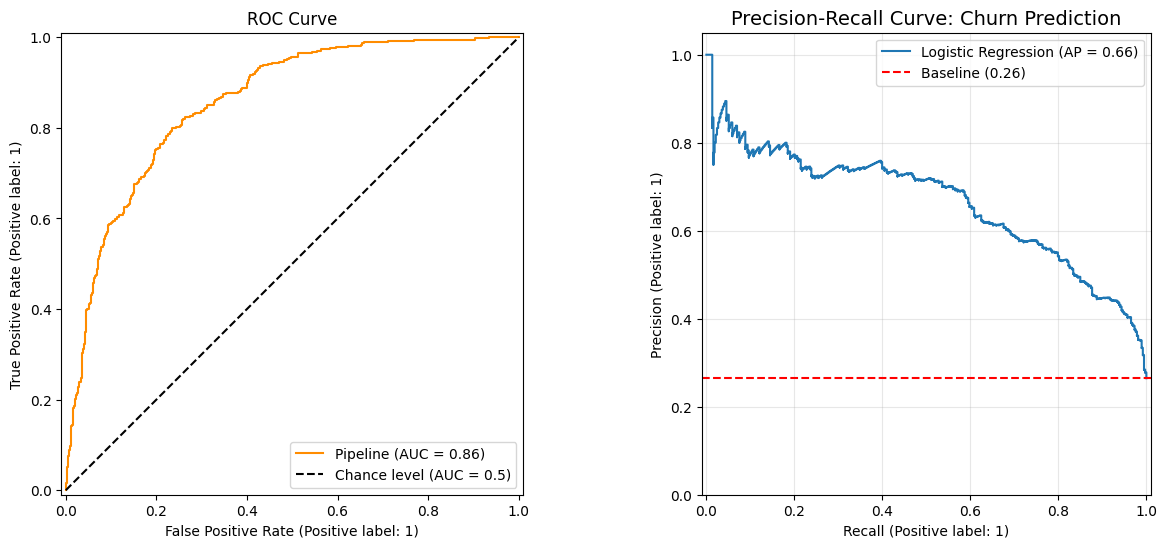

In [47]:
# Scaling
# Only scale numerical columns, not the 0-1 binary
columns_to_scale = ['MonthlyCharges', 'TotalCharges', 'TenureMonths']

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columns_to_scale)
    ],
    remainder='passthrough'
)

pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("lr", LogisticRegression(
        solver='liblinear', 
        class_weight='balanced', 
        max_iter=1000, 
        random_state=42
    ))
])

pipe_lr.fit(X_train_enc, y_train_enc)

#Prediction for both sets
train_pred_lr = pipe_lr.predict(X_train_enc)
test_pred_lr = pipe_lr.predict(X_test_enc)

train_probs_lr = pipe_lr.predict_proba(X_train_enc)[:, 1]
test_probs_lr = pipe_lr.predict_proba(X_test_enc)[:, 1]

'''
#Metrics
train_auc_roc_lr = roc_auc_score(y_train_enc, train_probs_lr)
train_recall_lr = recall_score(y_train_enc, train_pred_lr)
train_report_lr = classification_report(y_train_enc, train_pred_lr)
'''

test_accuracy_lr = accuracy_score(y_test_enc, test_pred_lr)
test_recall_lr = recall_score(y_test_enc, test_pred_lr)

test_auc_roc_lr = roc_auc_score(y_test_enc, test_probs_lr)
test_f1_lr = f1_score(y_test_enc, test_pred_lr)
test_report_lr = classification_report(y_test_enc, test_pred_lr)

ConfusionMatrixDisplay.from_estimator(pipe_lr, X_test_enc, y_test_enc, cmap='Blues')

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,6))

RocCurveDisplay.from_estimator(pipe_lr, X_test_enc, y_test_enc, ax=ax1, color='darkorange')
ax1.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)")
ax1.set_title("ROC Curve")
ax1.legend()

PrecisionRecallDisplay.from_estimator(pipe_lr, X_test_enc, y_test_enc, name="Logistic Regression", ax=ax2)
baseline = y_test_enc.sum() / len(y_test_enc)

ax2.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline ({baseline:.2f})')
ax2.set_title("Precision-Recall Curve: Churn Prediction", fontsize=14)
ax2.set_ylim([0.0, 1.05])
ax2.grid(alpha=0.3)
ax2.legend(loc="upper right")

'''
print("TRAIN SET PERFORMANCE")
print(f"auc_roc: {train_auc_roc_lr:.2f}")
print(f"recall: {train_recall_lr:.2f}")
print("report:", train_report_lr)
'''

print("LOGISTIC REGRESSION TEST SET PERFORMANCE")
print(f"accuracy: {test_accuracy_lr:.2f}")
print(f"recall: {test_recall_lr:.2f}")
print()
print(f"auc_roc: {test_auc_roc_lr:.2f}")
print(f"f1 score: {test_f1_lr:.2f}")
print()
print("report:", test_report_lr)

plt.tight_layout
plt.show()

#### Random Forest Classifier

In [48]:
# Use balanced class weight
model_rf = RandomForestClassifier(
        class_weight='balanced', 
        random_state=42
    )

# Define Hyperparameters for GridSearch
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 8, 12],
    'min_samples_leaf': [5, 10, 20]
}

# Run GridSearchCV
grid_rf = GridSearchCV(model_rf, param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train_enc, y_train_enc)



,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 8, ...], 'min_samples_leaf': [5, 10, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

--- FINAL MODEL TEST PERFORMANCE RANDOM FOREST ---
accuracy: 0.83
recall: 0.80

auc_roc: 0.89
f1: 0.71

report:               precision    recall  f1-score   support

           0       0.92      0.84      0.88      1036
           1       0.64      0.80      0.71       373

    accuracy                           0.83      1409
   macro avg       0.78      0.82      0.79      1409
weighted avg       0.84      0.83      0.83      1409



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


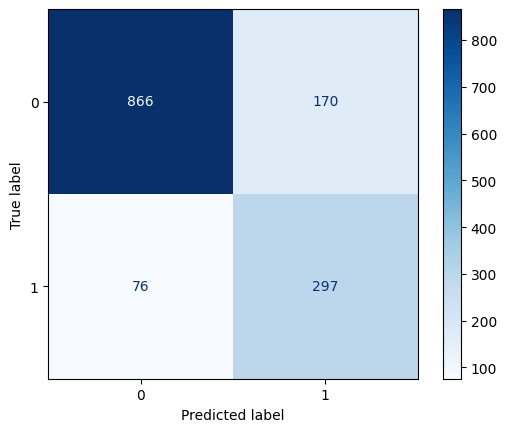

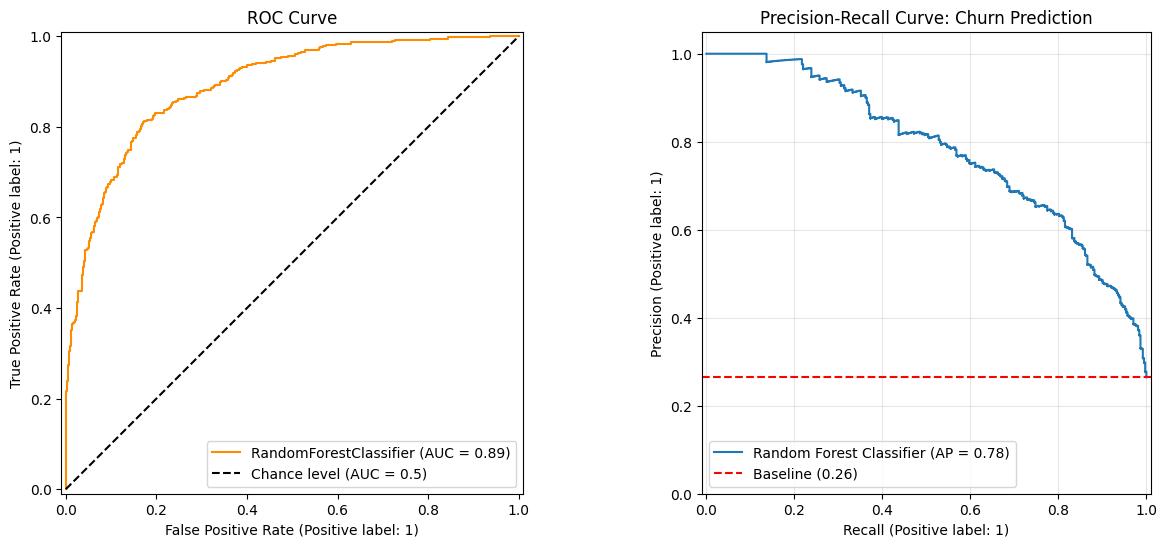

In [49]:
# Get the best model from the GridSearch
best_model_rf = grid_rf.best_estimator_

# Prediction for both sets
train_pred_rf = best_model_rf.predict(X_train_enc)
test_pred_rf = best_model_rf.predict(X_test_enc)

train_probs_rf = best_model_rf.predict_proba(X_train_enc)[:, 1]
test_probs_rf = best_model_rf.predict_proba(X_test_enc)[:, 1]

'''
# Train Metrics
train_auc_roc_rf = roc_auc_score(y_train_enc, train_probs_rf)
train_recall_rf = recall_score(y_train_enc, train_pred_rf)
train_report_rf = classification_report(y_train_enc, train_pred_rf)
'''

#Test Metrics
test_accuracy_rf = accuracy_score(y_test_enc, test_pred_rf)
test_recall_rf = recall_score(y_test_enc, test_pred_rf)

test_auc_roc_rf = roc_auc_score(y_test_enc, test_probs_rf)
test_f1_rf = f1_score(y_test_enc, test_pred_rf)
test_report_rf = classification_report(y_test_enc, test_pred_rf)

ConfusionMatrixDisplay.from_estimator(best_model_rf, X_test_enc, y_test_enc, cmap='Blues')

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,6))

RocCurveDisplay.from_estimator(best_model_rf, X_test_enc, y_test_enc, ax=ax1, color='darkorange')
ax1.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)")
ax1.set_title("ROC Curve")
ax1.legend()

PrecisionRecallDisplay.from_estimator(best_model_rf, X_test_enc, y_test_enc, name="Random Forest Classifier", ax=ax2)
baseline = y_test_enc.sum() / len(y_test_enc)
ax2.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline ({baseline:.2f})')
ax2.set_title("Precision-Recall Curve: Churn Prediction")
ax2.set_ylim([0.0, 1.05])
ax2.grid(alpha=0.3)
ax2.legend()

'''
print("--- FINAL MODEL TRAIN PERFORMANCE (1=CHURNED) ---")
print(f"auc_roc: {train_auc_roc_rf:.2f}")
print(f"recall: {train_recall_rf:.2f}")
print("report:", train_report_rf)
'''

print("--- FINAL MODEL TEST PERFORMANCE RANDOM FOREST ---")
print(f"accuracy: {test_accuracy_rf:.2f}")
print(f"recall: {test_recall_rf:.2f}")
print()
print(f"auc_roc: {test_auc_roc_rf:.2f}")
print(f"f1: {test_f1_rf:.2f}")
print()
print("report:", test_report_rf)

plt.tight_layout
plt.show()

#### CatBoost Classifier

In [50]:
# Set object type to category in non-encoded df
categorical_features = df_final.columns[df_final.dtypes=='object']

for col in categorical_features:
    df_final[col] = df_final[col].astype("category")

In [51]:
#Split
X = df_final.drop('Churned', axis=1)
y = df_final['Churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [52]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Type              7043 non-null   category
 1   PaperlessBilling  7043 non-null   category
 2   PaymentMethod     7043 non-null   category
 3   MonthlyCharges    7043 non-null   float64 
 4   TotalCharges      7043 non-null   float64 
 5   Churned           7043 non-null   int64   
 6   TenureMonths      7043 non-null   int32   
 7   Gender            7043 non-null   category
 8   SeniorCitizen     7043 non-null   int64   
 9   Partner           7043 non-null   category
 10  Dependents        7043 non-null   category
 11  InternetService   7043 non-null   category
 12  OnlineSecurity    7043 non-null   category
 13  OnlineBackup      7043 non-null   category
 14  DeviceProtection  7043 non-null   category
 15  TechSupport       7043 non-null   category
 16  StreamingTV       7043 n

In [53]:
# Let the model know which columns are categorical 
cat_features = X_train.select_dtypes(include=['category']).columns.tolist()
extra_cats = ['SeniorCitizen', 'HasInternet', 'HasPhone']
cat_features.extend([col for col in extra_cats if col in X_train.columns])

model_cat = CatBoostClassifier(auto_class_weights='Balanced', 
                               cat_features=cat_features, 
                               random_state=42, 
                               verbose=0)

param_grid_cat = {
    'depth': [4, 6, 8],
    'learning_rate': [0.03, 0.1],
    'l2_leaf_reg': [5, 10, 20]
}

# CatBoost havs a built-in .grid_search() function
grid_cat = model_cat.grid_search(param_grid_cat, 
                                 X=X_train, 
                                 y=y_train, 
                                 cv=5,
                                 refit=True)



bestTest = 0.4267714561
bestIteration = 978

0:	loss: 0.4267715	best: 0.4267715 (0)	total: 3.76s	remaining: 1m 3s

bestTest = 0.4282669794
bestIteration = 373

1:	loss: 0.4282670	best: 0.4267715 (0)	total: 7s	remaining: 56s

bestTest = 0.4349191212
bestIteration = 987

2:	loss: 0.4349191	best: 0.4267715 (0)	total: 10.3s	remaining: 51.4s

bestTest = 0.4312336853
bestIteration = 417

3:	loss: 0.4312337	best: 0.4267715 (0)	total: 13.4s	remaining: 46.7s

bestTest = 0.4373515734
bestIteration = 984

4:	loss: 0.4373516	best: 0.4267715 (0)	total: 16.2s	remaining: 42.1s

bestTest = 0.4285670153
bestIteration = 997

5:	loss: 0.4285670	best: 0.4267715 (0)	total: 19s	remaining: 38s

bestTest = 0.4303529782
bestIteration = 939

6:	loss: 0.4303530	best: 0.4267715 (0)	total: 22.9s	remaining: 35.9s

bestTest = 0.4351528395
bestIteration = 223

7:	loss: 0.4351528	best: 0.4267715 (0)	total: 26.5s	remaining: 33.2s

bestTest = 0.4355612919
bestIteration = 903

8:	loss: 0.4355613	best: 0.4267715 (0)	tota

--- FINAL MODEL TEST PERFORMANCE FOR CATBOOST ---
accuracy: 0.82
recall: 0.83

auc_roc: 0.92
f1: 0.71

report:               precision    recall  f1-score   support

           0       0.93      0.82      0.87      1036
           1       0.62      0.83      0.71       373

    accuracy                           0.82      1409
   macro avg       0.78      0.82      0.79      1409
weighted avg       0.85      0.82      0.83      1409



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


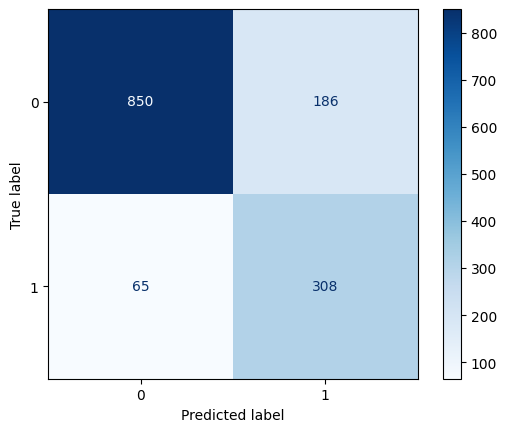

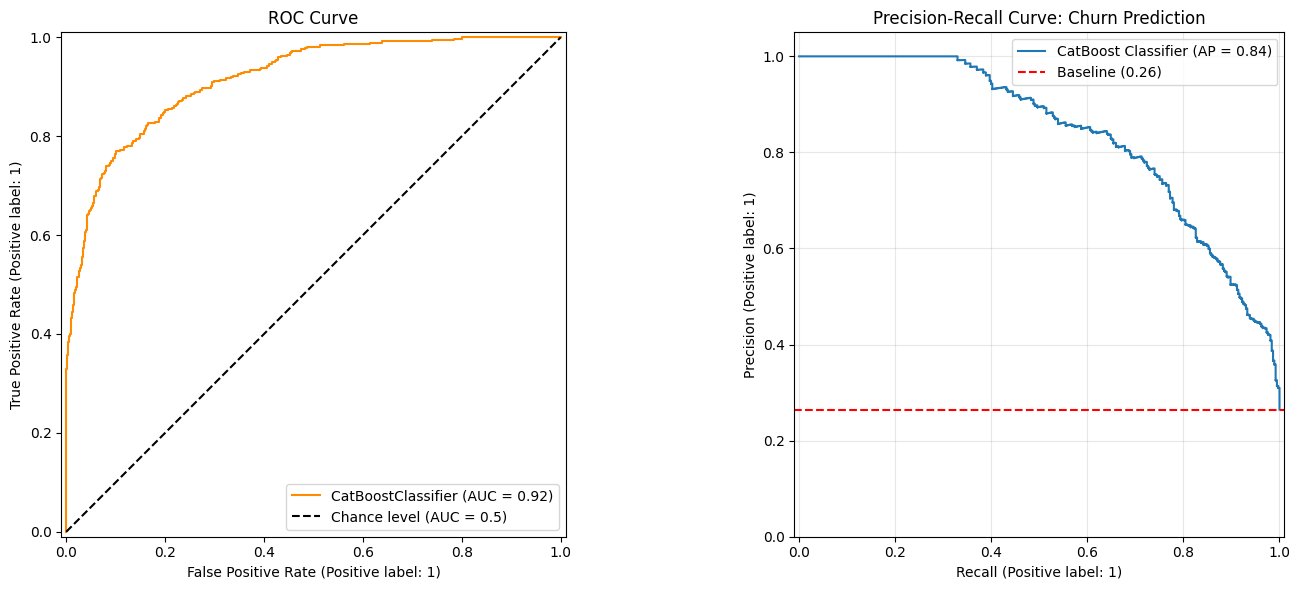

In [54]:
#Prediction on both sets
train_pred_cat = model_cat.predict(X_train)
test_pred_cat = model_cat.predict(X_test)

train_probs_cat = model_cat.predict_proba(X_train)[:, 1]
test_probs_cat = model_cat.predict_proba(X_test)[:, 1]

'''
#Metrics Train
train_auc_roc_cat = roc_auc_score(y_train, train_probs_cat)
train_recall_cat = recall_score(y_train, train_pred_cat)
train_report_cat = classification_report(y_train, train_pred_cat)
'''

#Metrics Tet
test_accuracy_cat = accuracy_score(y_test_enc, test_pred_cat)
test_recall_cat = recall_score(y_test_enc, test_pred_cat)

test_auc_roc_cat = roc_auc_score(y_test, test_probs_cat)
test_f1_cat = f1_score(y_test, test_pred_cat)
test_report_cat = classification_report(y_test, test_pred_cat)

ConfusionMatrixDisplay.from_estimator(model_cat, X_test, y_test, cmap='Blues')

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,6))

RocCurveDisplay.from_estimator(model_cat, X_test, y_test, ax=ax1, color='darkorange')
ax1.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)")
ax1.set_title("ROC Curve")
ax1.legend()

PrecisionRecallDisplay.from_estimator(model_cat, X_test, y_test, name="CatBoost Classifier", ax=ax2)
baseline = y_test_enc.sum() / len(y_test_enc)
ax2.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline ({baseline:.2f})')
ax2.set_title("Precision-Recall Curve: Churn Prediction")
ax2.set_ylim([0.0, 1.05])
ax2.grid(alpha=0.3)
ax2.legend()

'''
print("--- FINAL MODEL TRAIN PERFORMANCE (1=CHURNED) ---")
print(f"auc_roc: {train_auc_roc_cat:.2f}")
print(f"recall: {train_recall_cat:.2f}")
print("report:", train_report_cat)
'''

print("--- FINAL MODEL TEST PERFORMANCE FOR CATBOOST ---")
print(f"accuracy: {test_accuracy_cat:.2f}")
print(f"recall: {test_recall_cat:.2f}")
print()
print(f"auc_roc: {test_auc_roc_cat:.2f}")
print(f"f1: {test_f1_cat:.2f}")
print()
print("report:", test_report_cat)

plt.tight_layout()
plt.show()

#### XGB Classifier

In [55]:
# 'tree_method=hist' is required for categorical support
model_xgb = XGBClassifier(
    tree_method="hist", 
    enable_categorical=True, 
    eval_metric='logloss',
    scale_pos_weight=3 # Total negatives / Total positives, 75/25 (3:1 ratio)
)

# Define the parameters Grid
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'gamma': [0, 0.1, 0.2],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# XGBoost does not have a built-in .grid_search() like CatBoost
grid_xgb = GridSearchCV(
    estimator=model_xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 6, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramet

--- FINAL MODEL TEST PERFORMANCE FOR XGB ---
accuracy: 0.81
recall: 0.82

auc_roc: 0.91
f1: 0.70

report:               precision    recall  f1-score   support

           0       0.93      0.80      0.86      1036
           1       0.60      0.82      0.70       373

    accuracy                           0.81      1409
   macro avg       0.76      0.81      0.78      1409
weighted avg       0.84      0.81      0.82      1409



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


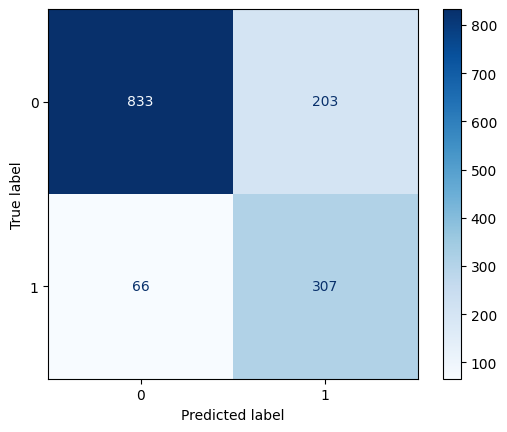

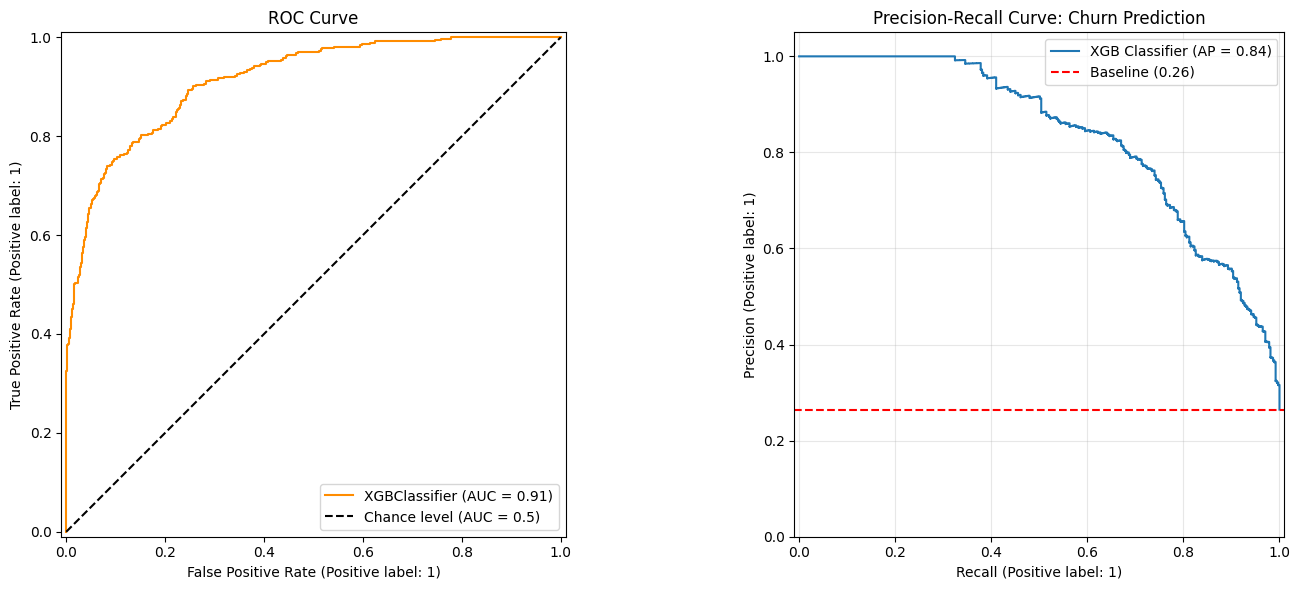

In [56]:
# Select best model
best_xgb = grid_xgb.best_estimator_

# Predict
train_pred_xgb = best_xgb.predict(X_train)
test_pred_xgb = best_xgb.predict(X_test)

train_probs_xgb = best_xgb.predict_proba(X_train)[:, 1]
test_probs_xgb = best_xgb.predict_proba(X_test)[:, 1]

'''
# Metrics Train
train_auc_roc_xgb = roc_auc_score(y_train, train_probs_xgb)
train_recall_xgb = recall_score(y_train, train_pred_xgb)
train_report_xgb = classification_report(y_train, train_pred_xgb)
'''

#Metrics Test
test_accuracy_xgb = accuracy_score(y_test_enc, test_pred_xgb)
test_recall_xgb = recall_score(y_test_enc, test_pred_xgb)

test_auc_roc_xgb = roc_auc_score(y_test, test_probs_xgb)
test_f1_xgb = f1_score(y_test, test_pred_xgb)
test_report_xgb = classification_report(y_test, test_pred_xgb)

ConfusionMatrixDisplay.from_estimator(best_xgb, X_test, y_test, cmap='Blues')

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,6))

RocCurveDisplay.from_estimator(best_xgb, X_test, y_test, ax=ax1, color='darkorange')
ax1.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)")
ax1.set_title("ROC Curve")
ax1.legend()

PrecisionRecallDisplay.from_estimator(best_xgb, X_test, y_test, name="XGB Classifier", ax=ax2)
baseline = y_test_enc.sum() / len(y_test_enc)
ax2.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline ({baseline:.2f})')
ax2.set_title("Precision-Recall Curve: Churn Prediction")
ax2.set_ylim([0.0, 1.05])
ax2.grid(alpha=0.3)
ax2.legend()

'''
print("--- FINAL MODEL TRAIN PERFORMANCE (1=CHURNED) ---")
print(f"auc_roc: {train_auc_roc_xgb:.2f}")
print(f"recall: {train_recall_xgb:.2f}")
print("report:", train_report_xgb)
'''

print("--- FINAL MODEL TEST PERFORMANCE FOR XGB ---")
print(f"accuracy: {test_accuracy_xgb:.2f}")
print(f"recall: {test_recall_xgb:.2f}")
print()
print(f"auc_roc: {test_auc_roc_xgb:.2f}")
print(f"f1: {test_f1_xgb:.2f}")
print()
print("report:", test_report_xgb)

plt.tight_layout()
plt.show()

#### LightGBM Classifier

In [57]:
#Define model
model_lgbm = LGBMClassifier(
    enable_categorical=True,
    scale_pos_weight=3, # Total negatives / Total positives, 75/25 (3:1 ratio)
    random_state=42,
    verbosity=-1 
)

# Define the parameters Grid
param_grid_lgbm = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [8, 15, 20, 32, 64],
    'min_data_in_leaf': [50],
    'lambda_l1': [0.1]
}

# Define GridSearch
grid_lgbm = GridSearchCV(
    estimator=model_lgbm,
    param_grid=param_grid_lgbm,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_lgbm.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie... verbosity=-1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'lambda_l1': [0.1], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_data_in_leaf': [50], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter cand

--- FINAL MODEL TEST_PERFORMANCE FOR LightGBM ---
accuracy: 0.83
recall: 0.83

auc_roc: 0.92
f1: 0.72

report:               precision    recall  f1-score   support

           0       0.93      0.84      0.88      1036
           1       0.65      0.83      0.72       373

    accuracy                           0.83      1409
   macro avg       0.79      0.83      0.80      1409
weighted avg       0.85      0.83      0.84      1409



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


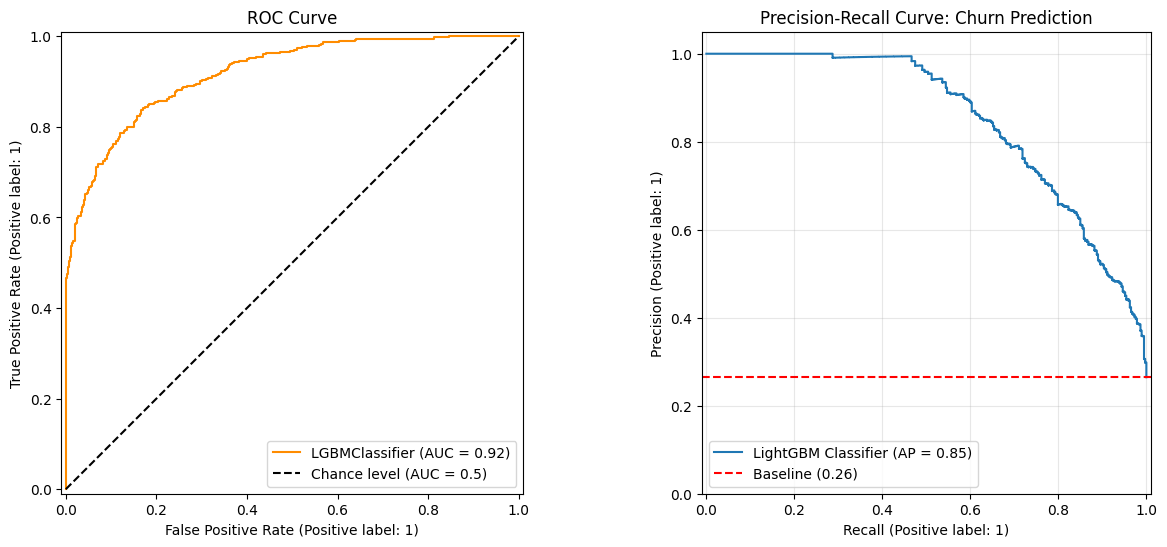

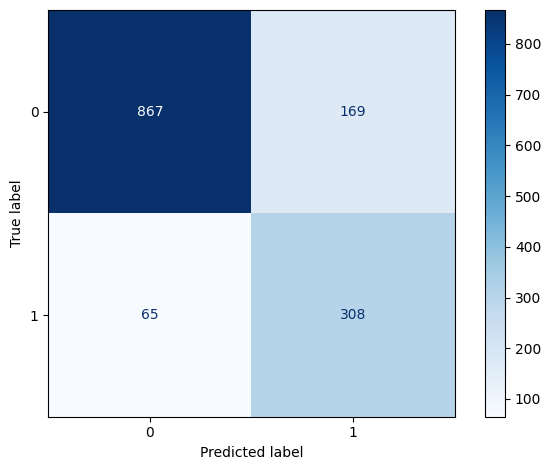

In [58]:
# Select best model
best_lgbm = grid_lgbm.best_estimator_

# Predict
#train_pred_lgbm = best_lgbm.predict(X_train)
test_pred_lgbm = best_lgbm.predict(X_test)

#train_probs_lgbm = best_lgbm.predict_proba(X_train)[:, 1]
test_probs_lgbm = best_lgbm.predict_proba(X_test)[:, 1]

'''
# Metrics Train
train_auc_roc_lgbm = roc_auc_score(y_train, train_probs_lgbm)
train_recall_lgbm = recall_score(y_train, train_pred_lgbm)
train_report_lgbm = classification_report(y_train, train_pred_lgbm)
'''

# Metrics
test_accuracy_lgbm = accuracy_score(y_test_enc, test_pred_lgbm)
test_recall_lgbm = recall_score(y_test_enc, test_pred_lgbm)

test_auc_roc_lgbm = roc_auc_score(y_test, test_probs_lgbm)
test_f1_lgbm = f1_score(y_test, test_pred_lgbm)
test_report_lgbm = classification_report(y_test, test_pred_lgbm)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,6))

ConfusionMatrixDisplay.from_estimator(best_lgbm, X_test, y_test, cmap='Blues')

RocCurveDisplay.from_estimator(best_lgbm, X_test, y_test, ax=ax1, color='darkorange')
ax1.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)")
ax1.set_title("ROC Curve")
ax1.legend()

PrecisionRecallDisplay.from_estimator(best_lgbm, X_test, y_test, name="LightGBM Classifier", ax=ax2)
baseline = y_test_enc.sum() / len(y_test_enc)
ax2.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline ({baseline:.2f})')
ax2.set_title("Precision-Recall Curve: Churn Prediction")
ax2.set_ylim([0.0, 1.05])
ax2.grid(alpha=0.3)
ax2.legend()

'''
print("--- FINAL MODEL TRAIN PERFORMANCE (1=CHURNED) ---")
print(f"auc_roc: {train_auc_roc_lgbm:.2f}")
print(f"recall: {train_recall_lgbm:.2f}")
print("report:", train_report_lgbm)
'''

print("--- FINAL MODEL TEST_PERFORMANCE FOR LightGBM ---")
print(f"accuracy: {test_accuracy_lgbm:.2f}")
print(f"recall: {test_recall_lgbm:.2f}")
print()
print(f"auc_roc: {test_auc_roc_lgbm:.2f}")
print(f"f1: {test_f1_lgbm:.2f}")
print()
print("report:", test_report_lgbm)

plt.tight_layout()
plt.show()

#### Models comparison

| Model | Recall | F1 | Accuracy | AUC-ROC |
|:-------|------:|------:|------:|------:|
| Dummy Classifier (Baseline) | 0.00 | 0.00 | 0.74 | 0.5 |
| Logistic Regression | 0.83 | 0.64| 0.75 | 0.86 |
| Random Forest Classifier | 0.80 | 0.71 | 0.83 | 0.89 |
| CatBoost | 0.83 | 0.71 | 0.82 | 0.92 |
| XGBoost | 0.82 | 0.70 | 0.81 | 0.91 |
| LightGBM | 0.83 | 0.72 | 0.83 | 0.92 |

Best model LightGBM

- num_leaves	20
- max_depth	5
- n_estimators	300
- random_state	42
- enable_categorical	True
- scale_pos_weight	3
- verbosity	-1
- lambda_l1	0.1
- min_data_in_leaf	50

The project successfully developed a predictive model to identify customer churn with a Recall of 83%, effectively capturing the vast majority of potential revenue loss.</br>

While the F1-score of 0.72 reflects a trade-off in Precision, the model is optimized for proactive intervention.</br>

By identifying 8 out of 10 churners before they leave, the business can shift from a reactive approach to a proactive retention strategy, significantly increasing the potential for long-term Customer Lifetime Value (CLV).

In [59]:
# Obtain features from predicted churned
pred_series = pd.Series(test_pred_lgbm, index=X_test.index, name='prediction')

X_test_with_preds = pd.concat([X_test, pred_series], axis=1)

In [60]:
# Monthly revenue of predicted churned
churned_sum = X_test_with_preds[X_test_with_preds['prediction'] == 1]['MonthlyCharges'].sum()
print(churned_sum)

37024.4


The model identified $37,024.40 in Monthly Recurring Revenue (MRR) currently at risk.